# LANL Cyber 1: temporal attack graph

This notebook connects a small, known red-team sample to authentication events in a configurable relative-time window. It does not perform anomaly detection or machine learning.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_auth_events_window, load_redteam_events
from src.graph_builder import (
    build_attack_graph,
    find_related_auth_events,
    get_attack_path,
)

AUTH_PATH = PROJECT_ROOT / 'data' / 'raw' / 'auth.txt.gz'
REDTEAM_PATH = PROJECT_ROOT / 'data' / 'raw' / 'redteam.txt.gz'
BEFORE = 300
AFTER = 300
REDTEAM_SAMPLE_SIZE = 15

# Only the first 15 known red-team events are loaded for this first graph.
redteam = load_redteam_events(REDTEAM_PATH, max_rows=REDTEAM_SAMPLE_SIZE)
display(redteam)

,timestamp,user,source_computer,destination_computer
0,150885,U620@DOM1,C17693,C1003
1,151036,U748@DOM1,C17693,C305
2,151648,U748@DOM1,C17693,C728
3,151993,U6115@DOM1,C17693,C1173
4,153792,U636@DOM1,C17693,C294
5,155219,U748@DOM1,C17693,C5693
6,155399,U748@DOM1,C17693,C152
7,155460,U748@DOM1,C17693,C2341
8,155591,U748@DOM1,C17693,C332
9,156658,U748@DOM1,C17693,C4280


## Matching rule

An auth event is considered related when its timestamp is between the red-team timestamp minus `BEFORE` and plus `AFTER`, inclusive, and it shares at least one exact entity with the red-team event. The entities are the red-team user, source computer, or destination computer. A shared user connects account activity; shared computers connect activity occurring on the source or targeted host. This is a contextual association, not proof that the auth event is malicious.

In [2]:
window_start = int(redteam['timestamp'].min()) - BEFORE
window_end = int(redteam['timestamp'].max()) + AFTER

# The loader streams the gzip file and stores only this timestamp window.
auth_window = load_auth_events_window(
    AUTH_PATH,
    start_timestamp=window_start,
    end_timestamp=window_end,
)
related_auth = find_related_auth_events(redteam, auth_window, BEFORE, AFTER)

counts = pd.DataFrame([
    {
        'redteam_id': redteam_id,
        'redteam_timestamp': int(redteam.iloc[int(redteam_id.removeprefix('rt-'))]['timestamp']),
        'user': redteam.iloc[int(redteam_id.removeprefix('rt-'))]['user'],
        'related_auth_count': len(events),
    }
    for redteam_id, events in related_auth.items()
])
display(counts)
print('Auth rows retained in timestamp window:', len(auth_window))

,redteam_id,redteam_timestamp,user,related_auth_count
0,rt-0,150885,U620@DOM1,15
1,rt-1,151036,U748@DOM1,20
2,rt-2,151648,U748@DOM1,39
3,rt-3,151993,U6115@DOM1,11
4,rt-4,153792,U636@DOM1,37
5,rt-5,155219,U748@DOM1,34
6,rt-6,155399,U748@DOM1,33
7,rt-7,155460,U748@DOM1,35
8,rt-8,155591,U748@DOM1,32
9,rt-9,156658,U748@DOM1,16


Auth rows retained in timestamp window: 14086748


## Build and summarize the graph

In [3]:
graph = build_attack_graph(redteam, auth_window, BEFORE, AFTER)
node_types = pd.Series(nx.get_node_attributes(graph, 'type'), name='node_type').value_counts()
edge_types = pd.Series([data['relationship'] for _, _, data in graph.edges(data=True)], name='edge_type').value_counts()

print('Number of nodes:', graph.number_of_nodes())
print('Number of edges:', graph.number_of_edges())
print('Node types:')
display(node_types.to_frame('count'))
print('Edge types:')
display(edge_types.to_frame('count'))
print('Temporal records:', len(graph.graph['temporal_events']))

Number of nodes: 73
Number of edges: 695
Node types:


,count
node_type,
COMPUTER,49
USER,24


Edge types:


,count
edge_type,
AUTHENTICATED_TO,680
REDTEAM_TARGET,15


Temporal records: 695


## One concrete red-team neighborhood

In [4]:
example = get_attack_path(graph, redteam_event=0, max_hops=2)
print('Selected event:', example['redteam_id'])
display(pd.DataFrame([example['redteam_event']]))
print('Authentication events used for this neighborhood:', len(example['related_auth_events']))
display(example['related_auth_events'])
print('Simple paths within two hops:', example['paths'][:5])

Selected event: rt-0


,timestamp,user,source_computer,destination_computer
0,150885,U620@DOM1,C17693,C1003


Authentication events used for this neighborhood: 15


,timestamp,source_user,destination_user,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,status,match_reasons,redteam_id
0,150641,U208@DOM1,U208@DOM1,C1003,C1003,?,Network,LogOff,Success,[destination_computer],rt-0
1,150761,U748@DOM1,U748@DOM1,C1003,C1003,?,Network,LogOff,Success,[destination_computer],rt-0
2,150786,U620@DOM1,U620@DOM1,C17693,C1759,NTLM,Network,LogOn,Success,"[user, source_computer]",rt-0
3,150821,U522@DOM1,U522@DOM1,C1003,C1003,?,Network,LogOff,Success,[destination_computer],rt-0
4,150847,U620@DOM1,U620@DOM1,C17693,C1759,NTLM,Network,LogOn,Success,"[user, source_computer]",rt-0
5,150882,U111@DOM1,U111@DOM1,C1003,C1003,?,Network,LogOff,Success,[destination_computer],rt-0
6,150885,U620@DOM1,U620@DOM1,C17693,C1003,NTLM,Network,LogOn,Success,"[user, source_computer, destination_computer]",rt-0
7,150941,U560@DOM1,U560@DOM1,C1003,C1003,?,Network,LogOff,Success,[destination_computer],rt-0
8,150995,U620@DOM1,U620@DOM1,C1759,C1759,?,Network,LogOff,Success,[user],rt-0
9,151004,ANONYMOUS LOGON@C528,ANONYMOUS LOGON@C528,C1003,C528,NTLM,Network,LogOn,Success,[destination_computer],rt-0


Simple paths within two hops: [['COMPUTER:C17693', 'COMPUTER:C1003']]


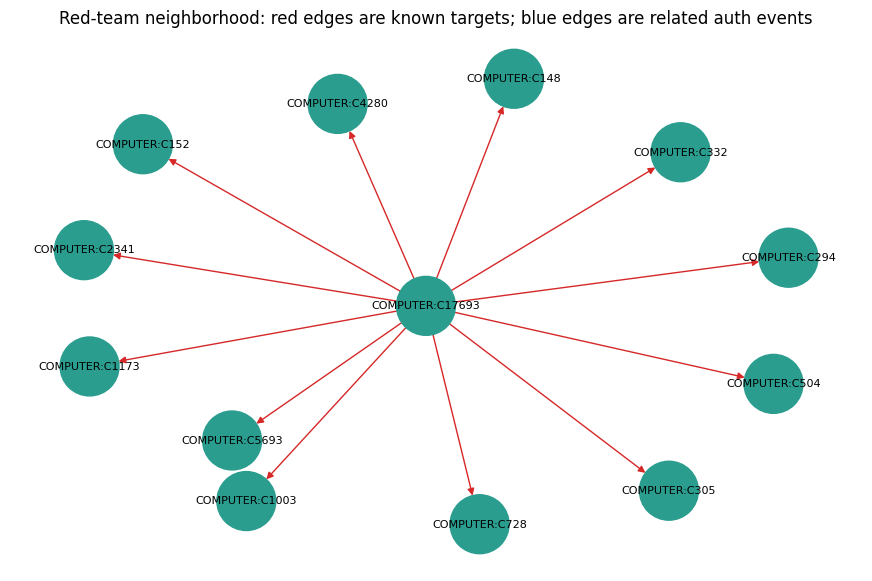

In [5]:
neighborhood_graph = example['graph']
positions = nx.spring_layout(neighborhood_graph, seed=7)
node_colors = [
    '#f4a261' if neighborhood_graph.nodes[node]['type'] == 'USER' else '#2a9d8f'
    for node in neighborhood_graph.nodes
]
edge_colors = [
    '#d62828' if data['relationship'] == 'REDTEAM_TARGET' else '#457b9d'
    for _, _, data in neighborhood_graph.edges(data=True)
]

plt.figure(figsize=(11, 7))
nx.draw_networkx(
    neighborhood_graph,
    positions,
    node_color=node_colors,
    edge_color=edge_colors,
    with_labels=True,
    node_size=1800,
    font_size=8,
    arrows=True,
)
plt.title('Red-team neighborhood: red edges are known targets; blue edges are related auth events')
plt.axis('off')
plt.show()

## Assumptions and limitations

- Every selected red-team row is included as a `REDTEAM_TARGET` edge because LANL defines it as known compromise activity.
- An auth row is included only when it falls in the configured inclusive time window and shares an exact user or computer identifier.
- Auth edges use `source_user -> destination_computer`; the remaining original auth fields are retained as edge attributes.
- Shared identifiers and close timestamps can still create false associations: normal activity by the same account or host may surround a red-team event.
- The graph shows temporal context and ground-truth labels; it does not establish causality, maliciousness of every neighboring auth event, or an attack path by itself.
- LANL timestamps are relative seconds, so this notebook does not convert them into calendar datetimes.